PRIMEIRA CÉLULA (IMPORTAÇÕES)

In [1]:
import pandas as pd
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

PASTAS DO PROJETO

In [2]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)
os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)
os.makedirs("data/final", exist_ok=True)
os.makedirs("outputs/graficos", exist_ok=True)

print("Pastas criadas com sucesso")

Pastas criadas com sucesso


GERAR DATASET (RF01)

In [3]:
def gerar_dataset_vendas(n_registros=150, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse']
    precos = {
        'Notebook': 3500,
        'Smartphone': 2200,
        'Tablet': 1800,
        'Monitor': 1200,
        'Teclado': 250,
        'Mouse': 120
    }

    categorias = {
        "Notebook": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Monitor": "Computadores",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos"
    }

    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto]
        data = data_inicio + timedelta(days=random.randint(0, 364))

        if random.random() < 0.05:
            quantidade = None
        if random.random() < 0.04:
            preco = None
        if random.random() < 0.03:
            produto = "  " + produto

        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)


df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("data/raw/vendas.csv", index=False)

df_bruto.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0


INSPEÇÃO DOS DADOS (RF02)

In [4]:
def inspecionar_dados(df):
    print("SHAPE:", df.shape)
    print("\nCOLUNAS:", df.columns)
    print("\nTIPOS:\n", df.dtypes)
    print("\nNULOS:\n", df.isnull().sum())
    print("\nAMOSTRA:\n", df.head())

inspecionar_dados(df_bruto)

SHAPE: (150, 8)

COLUNAS: Index(['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao',
       'quantidade', 'preco_unitario'],
      dtype='object')

TIPOS:
 id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

NULOS:
 id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

AMOSTRA:
    id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores           Sul   
2         3  DATA INVALIDA  Cliente_026     Mouse   Periféricos           Sul   
3         4     2024-06-23  Cliente_013     Mouse   Periféricos       Sudeste   
4    

LIMPEZA DE DADOS (RF03)

In [5]:
import re

def limpar_strings_regex(df, colunas):
    df = df.copy()

    for col in colunas:
        df[col] = df[col].apply(
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s
        )

    return df

FUNÇÃO PRINCIPAL DE LIMPEZA

In [6]:
def limpar_dados(df):
    df = df.copy()
    n_inicial = len(df)

    # 1. limpar strings
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # 2. tratar datas inválidas
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")

    # remove datas inválidas
    df = df.dropna(subset=["data_venda"])

    # 3. remover nulos críticos
    df = df.dropna(subset=["quantidade", "preco_unitario"])

    # 4. corrigir tipos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    print("Registros iniciais:", n_inicial)
    print("Registros finais:", len(df))
    print("Registros removidos:", n_inicial - len(df))

    return df

EXECUTAR LIMPEZA

In [7]:
df_limpo = limpar_dados(df_bruto)
df_limpo.head()

Registros iniciais: 150
Registros finais: 140
Registros removidos: 10


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0


SALVAR V1 (COM OUTLIERS)

In [8]:
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)

df_limpo.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)

print("V1 salva com sucesso")

V1 salva com sucesso


OUTLIERS (v1 → v2) - RF04

OUTLIERS (IQR)

In [9]:
def tratar_outliers(df, colunas, fator=1.5, metodo="remover"):
    df = df.copy()

    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr

        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f"{col}: {n_out} outliers")

        if metodo == "remover":
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            df[col] = df[col].clip(lim_inf, lim_sup)

    return df

V1 E V2

In [10]:
# v1 já é seu df_limpo (com outliers)
df_v1 = df_limpo.copy()

# criar receita temporária para detectar outliers
df_temp = df_v1.copy()
df_temp["receita_total"] = df_temp["quantidade"] * df_temp["preco_unitario"]

# aplicar outliers
df_v2 = tratar_outliers(
    df_temp,
    colunas=["quantidade", "receita_total"],
    metodo="remover"
)

# remover coluna temporária
df_v2 = df_v2.drop(columns=["receita_total"])

print("\nV1 linhas:", len(df_v1))
print("V2 linhas:", len(df_v2))
print("Diferença removida:", len(df_v1) - len(df_v2))

quantidade: 0 outliers
receita_total: 6 outliers

V1 linhas: 140
V2 linhas: 134
Diferença removida: 6


SALVAR V2

In [11]:
os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)

df_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)

print("V2 salva com sucesso")

V2 salva com sucesso


COLUNAS DERIVADAS - RF05

FUNÇÃO DE COLUNAS DERIVADAS

In [12]:
def criar_colunas_derivadas(df):
    df = df.copy()

    # 1. receita total
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # 2. data já deve estar em datetime
    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year

    # 3. faixa de receita
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]

    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]

    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("Colunas criadas com sucesso!")
    print(df[["receita_total", "mes", "trimestre", "faixa_receita_item"]].head())

    return df

BASE (USE V2)

In [13]:
df = criar_colunas_derivadas(df_v2)

df.head()

Colunas criadas com sucesso!
   receita_total  mes trimestre faixa_receita_item
0          240.0    1        Q1        Baixo Valor
3          840.0    6        Q2        Médio Valor
4        10800.0   11        Q4         Alto Valor
6        14000.0    5        Q2         Alto Valor
7        13200.0    6        Q2         Alto Valor


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,trimestre,ano,faixa_receita_item
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0,240.0,1,Q1,2024,Baixo Valor
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0,840.0,6,Q2,2024,Médio Valor
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0,10800.0,11,Q4,2024,Alto Valor
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0,14000.0,5,Q2,2024,Alto Valor
7,8,2024-06-30,Cliente_020,Smartphone,Celulares,Sul,6,2200.0,13200.0,6,Q2,2024,Alto Valor


GROUPBY - RF06

FUNÇÃO DE MÉTRICAS

In [14]:
def calcular_metricas(df):
    metricas = {}

    # 1. Receita por mês
    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),
              quantidade=("quantidade", "sum"),
              n_vendas=("id_venda", "count")
          )
          .reset_index()
          .sort_values("mes")
    )

    # 2. Top 5 produtos
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )

    # 3. Receita por categoria
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # 4. Receita por região
    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(
              receita_total=("receita_total", "sum"),
              media_ticket=("receita_total", "mean")
          )
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # mostrar no console
    for nome, tabela in metricas.items():
        print("\n===", nome.upper(), "===")
        print(tabela)

    return metricas

EXECUTAR MÉTRICAS

In [15]:
metricas = calcular_metricas(df)


=== POR_MES ===
    mes  receita_total  quantidade  n_vendas
0     1        55690.0          52        10
1     2        60840.0          60        12
2     3        49050.0          62        11
3     4       143040.0          73        13
4     5        99390.0          85        15
5     6        81940.0          50         8
6     7        79780.0          64        13
7     8        66280.0          50        12
8     9        30280.0          39         8
9    10        89450.0          49        11
10   11       114950.0          74        13
11   12        57760.0          49         8

=== TOP_PRODUTOS ===
      produto  receita_total
0      Tablet       261000.0
1  Smartphone       257400.0
2    Notebook       227500.0
3     Monitor       134400.0
4     Teclado        30750.0

=== POR_CATEGORIA ===
      categoria  receita_total
0     Celulares       518400.0
1  Computadores       361900.0
2   Periféricos        48150.0

=== POR_REGIAO ===
         regiao  receita_total  med

SEGMENTAÇÃO DE CLIENTES - RF07

FUNÇÃO DE SEGMENTAÇÃO

In [16]:
def segmentar_clientes(df):
    # soma total por cliente
    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )

    clientes_df.columns = ["cliente", "total_gasto"]

    # classificação com lambda (OBRIGATÓRIO no enunciado)
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze")
    )

    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)

    print("Top 10 clientes:")
    print(clientes_df.head(10))

    print("\nDistribuição de segmentos:")
    print(clientes_df["segmento"].value_counts())

    return clientes_df

EXECUTAR SEGMENTAÇÃO

ESTATÍSTICAS COM NUMPY - RF08

In [17]:
def calcular_estatisticas_numpy(df):
    receitas = df["receita_total"].to_numpy()

    stats = {
        "media": float(np.mean(receitas)),
        "mediana": float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total": float(np.sum(receitas)),
        "p25": float(np.percentile(receitas, 25)),
        "p75": float(np.percentile(receitas, 75)),
    }

    # broadcasting (NumPy automático)
    perc = (receitas / receitas.sum()) * 100

    print("=== ESTATÍSTICAS NUMPY ===")
    for k, v in stats.items():
        print(f"{k}: {v:.2f}")

    print("\nTop 5 participações (%) das vendas:")
    print(np.sort(perc)[-5:])

    # quantos acima da média
    acima_media = (receitas > stats["media"]).sum()
    stats["acima_da_media"] = int(acima_media)

    print(f"\nVendas acima da média: {acima_media}")

    return stats

EXECUTAR

In [18]:
stats = calcular_estatisticas_numpy(df)

=== ESTATÍSTICAS NUMPY ===
media: 6928.73
mediana: 5100.00
desvio_padrao: 6449.66
total: 928450.00
p25: 1200.00
p75: 10800.00

Top 5 participações (%) das vendas:
[2.26183424 2.36954063 2.36954063 2.63880661 2.63880661]

Vendas acima da média: 60


GRÁFICOS RF09 (Matplotlib + Seaborn)

FUNÇÃO DE GRÁFICOS

In [19]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")

    # -------------------------
    # 1. GRÁFICO DE LINHA (MES)
    # -------------------------
    plt.figure(figsize=(10,5))

    pm = metricas["por_mes"]
    plt.plot(pm["mes"], pm["receita_total"], marker="o")

    plt.title("Receita Total por Mês")
    plt.xlabel("Mês")
    plt.ylabel("Receita Total")

    plt.xticks(range(1,13))

    plt.savefig(f"{output_dir}/receita_por_mes.png")
    plt.show()
    plt.close()

    # -------------------------
    # 2. BARRAS (TOP PRODUTOS)
    # -------------------------
    plt.figure(figsize=(10,5))

    sns.barplot(data=metricas["top_produtos"],
                x="receita_total",
                y="produto")

    plt.title("Top 5 Produtos por Receita")
    plt.xlabel("Receita")
    plt.ylabel("Produto")

    plt.savefig(f"{output_dir}/top_produtos.png")
    plt.show()
    plt.close()

    # -------------------------
    # 3. BOXPLOT (REGIÃO)
    # -------------------------
    plt.figure(figsize=(10,5))

    sns.boxplot(data=df,
                x="regiao",
                y="receita_total")

    plt.title("Distribuição de Receita por Região")
    plt.xlabel("Região")
    plt.ylabel("Receita")

    plt.xticks(rotation=30)

    plt.savefig(f"{output_dir}/box_regiao.png")
    plt.show()
    plt.close()

    print("Gráficos salvos em:", output_dir)

EXECUTAR GRÁFICOS

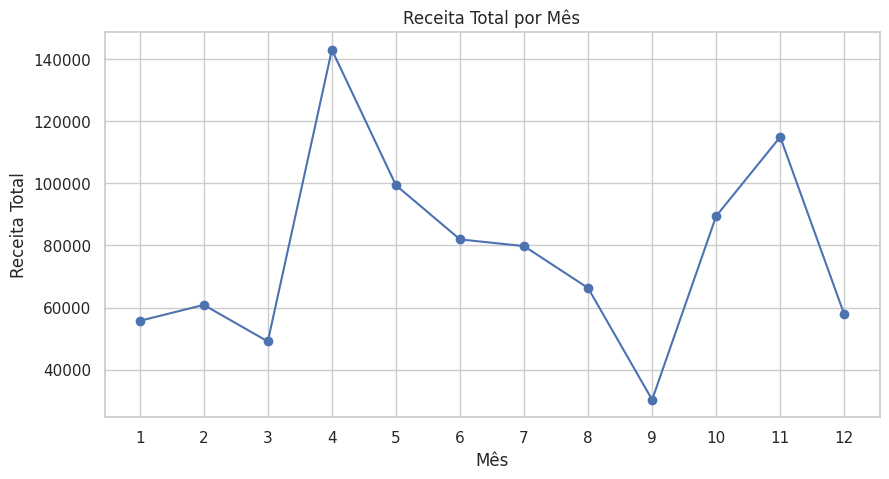

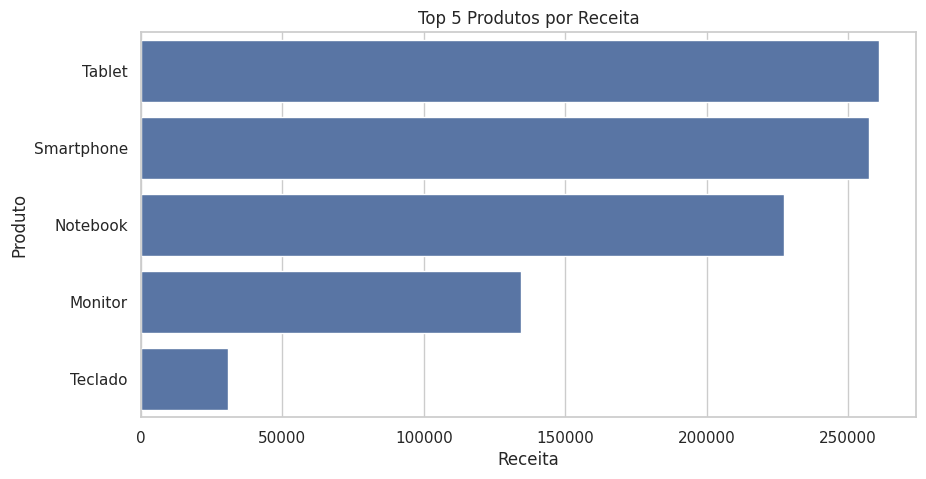

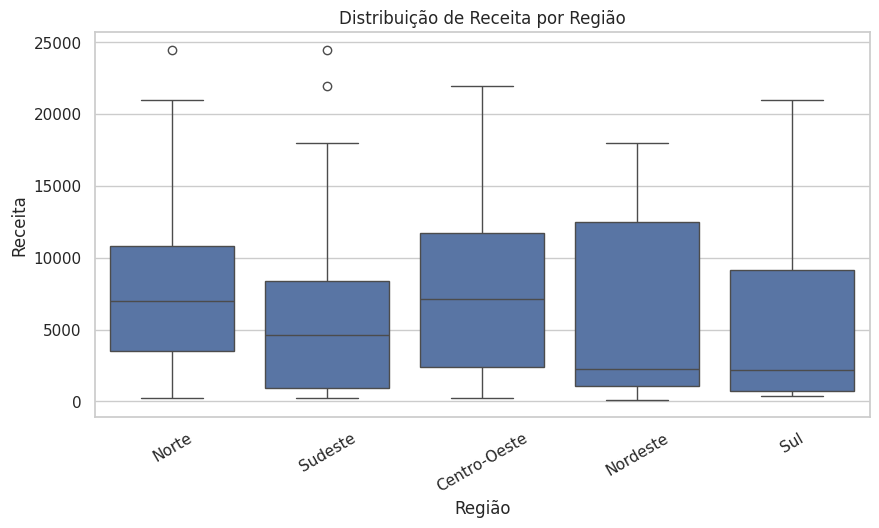

Gráficos salvos em: outputs/graficos


In [20]:
gerar_visualizacoes(df, metricas)

FUNÇÕES REUTILIZÁVEIS RF10 (ARQUITETURA DO PROJETO)

FUNÇÃO GENÉRICA (ORDEM SUPERIOR)

In [21]:
def aplicar_transformacao(df, coluna, funcao):
    """
    Função de ordem superior:
    aplica uma função em uma coluna e cria uma nova versão transformada.
    """

    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)

    return df

TESTAR COM LAMBDA (OBRIGATÓRIO)

In [22]:
# Exemplo 1: classificar receita
df_teste = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: "Alto" if x > 5000 else "Normal"
)

df_teste[["receita_total", "receita_total_transformado"]].head()

,receita_total,receita_total_transformado
0,240.0,Normal
3,840.0,Normal
4,10800.0,Alto
6,14000.0,Alto
7,13200.0,Alto


OUTRO USO (SEGUNDO LAMBDA)

In [23]:
# Exemplo 2: converter para milhar
df_teste2 = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: round(x / 1000, 2)
)

df_teste2[["receita_total", "receita_total_transformado"]].head()

,receita_total,receita_total_transformado
0,240.0,0.24
3,840.0,0.84
4,10800.0,10.80
6,14000.0,14.00
7,13200.0,13.20


EXPORTAÇÃO RF11 (CSV + JSON)

FUNÇÃO DE EXPORTAÇÃO

In [24]:
import json

def exportar_resultados(metricas, clientes, stats):
    os.makedirs("outputs", exist_ok=True)

    # -------------------
    # CSVs
    # -------------------
    metricas["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv",
        index=False,
        encoding="utf-8-sig"
    )

    clientes.to_csv(
        "outputs/segmentacao_clientes.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # -------------------
    # JSON
    # -------------------
    stats_serializaveis = {k: float(v) for k, v in stats.items()}

    caminho = "outputs/estatisticas_gerais.json"

    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)

    # -------------------
    # leitura de volta (prova de funcionamento)
    # -------------------
    with open(caminho, "r", encoding="utf-8") as f:
        leitura = json.load(f)

    print("CSV e JSON exportados com sucesso!")
    print("\nConteúdo do JSON lido de volta:")
    print(leitura)

    return True

EXECUTAR EXPORTAÇÃO

In [25]:
clientes = segmentar_clientes(df)
exportar_resultados(metricas, clientes, stats)

Top 10 clientes:
        cliente  total_gasto segmento
16  Cliente_018      67840.0     Ouro
12  Cliente_014      67160.0     Ouro
3   Cliente_004      61800.0     Ouro
27  Cliente_029      52330.0     Ouro
22  Cliente_024      51940.0     Ouro
17  Cliente_019      48010.0     Ouro
7   Cliente_008      47940.0     Ouro
18  Cliente_020      44800.0     Ouro
13  Cliente_015      43040.0     Ouro
2   Cliente_003      33200.0     Ouro

Distribuição de segmentos:
segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64
CSV e JSON exportados com sucesso!

Conteúdo do JSON lido de volta:
{'media': 6928.731343283582, 'mediana': 5100.0, 'desvio_padrao': 6449.662425696054, 'total': 928450.0, 'p25': 1200.0, 'p75': 10800.0, 'acima_da_media': 60.0}


True

DATASET FINAL + CONCLUSÃO DO PIPELINE - RF12

DATASET FINAL

In [26]:
os.makedirs("data/final", exist_ok=True)

df_final = df.copy()

df_final.to_csv("data/final/vendas_final.csv", index=False)

print("Dataset final salvo com sucesso!")
print("Linhas finais:", len(df_final))

Dataset final salvo com sucesso!
Linhas finais: 134
